In [1]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [2]:
col = pd.read_pickle('/Volumes/easystore/proton-deuteron/col&ind/chi-col.pkl')
ind = pd.read_pickle('/Volumes/easystore/proton-deuteron/col&ind/chi-ind.pkl')

In [3]:
removed_indices_col = col[~((col['height'] > 15) & (col['height'] < 179) & (col['width'] < 1500))].index            # remove long and wide images
removed_indices_ind = ind[~((ind['height'] > 15) & (ind['height'] < 179) & (ind['width'] < 1500))].index


removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

(7877, 43)
(7877, 43)


In [28]:
kaons = col[col['particle_type'] == 'kaon'].reset_index(drop=True)
protons = col[col['particle_type'] == 'proton'].reset_index(drop=True)

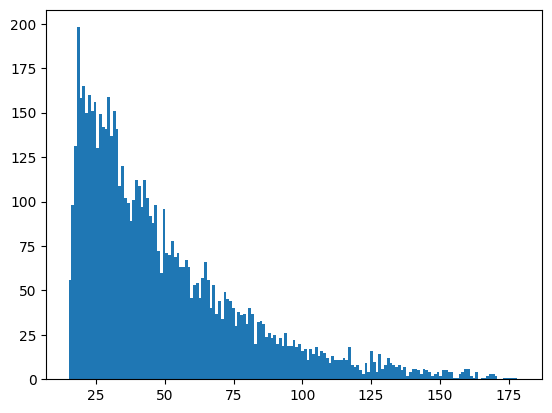

In [25]:
bins = np.linspace(15, 179, 164)
plt.hist(protons['height'], bins=bins)
plt.show()

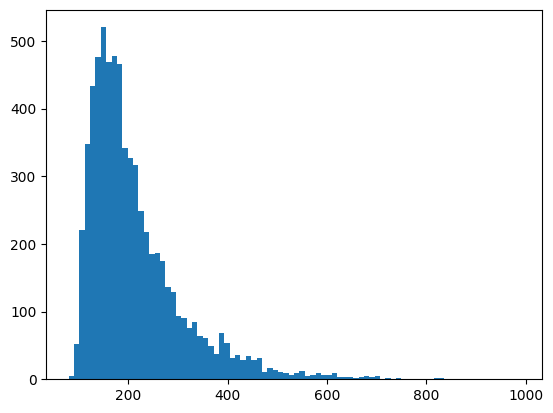

In [38]:
bins = np.linspace(0, 1499, 1499)
plt.hist(protons['width'], bins='auto')
plt.show()

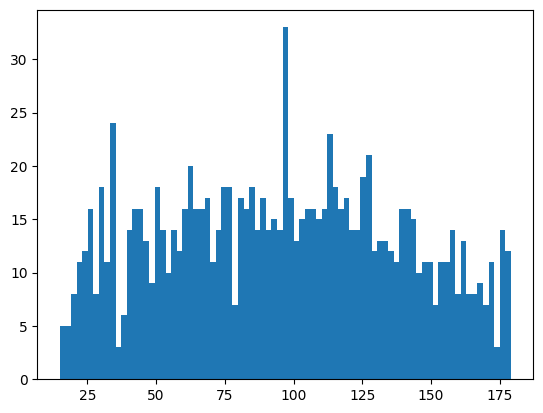

In [40]:
bins = np.linspace(15, 179, 82)
plt.hist(kaons['height'], bins=bins)
plt.show()

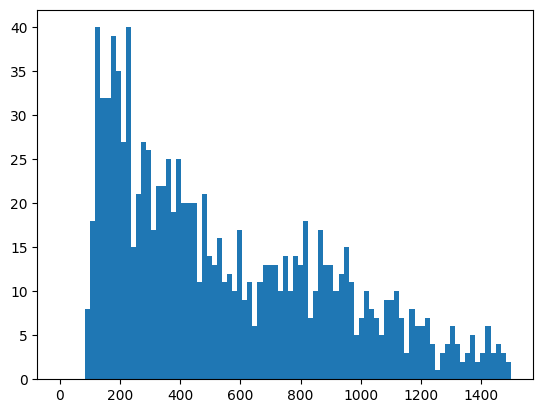

In [46]:
bins = np.linspace(0, 1499, 90)
plt.hist(kaons['width'], bins=bins)
plt.show()